# Random Forest Regression: In-depth Intuition

##  Introduction
Random Forest is an **ensemble learning method** that combines multiple decision trees to improve predictive accuracy and robustness.  
This notebook focuses mainly on **Regression tasks**, while also touching upon Classification briefly.

---

##  Key Concepts

#### 1. Ensemble Learning
- Random Forest is an **ensemble technique**.
- It builds many decision trees and combines their outputs.
- The idea: "Many weak learners together become a strong learner."

#### 2. Core Mechanism
- During training, Random Forest constructs multiple decision trees.
- Each tree is trained on a random subset of data and features.
- Predictions are averaged (for regression) or voted (for classification).

#### 3. Regression with Random Forest
- For regression problems, each tree predicts a numeric value.
- The final output is the **average of all tree predictions**.
- This reduces variance and improves stability compared to a single decision tree.

#### 4. Classification with Random Forest
- For classification problems, each tree predicts a class.
- The final output is the **majority class** chosen by the trees.
- This reduces overfitting and increases accuracy.

#### 5. Applications
- Regression tasks: predicting house prices, salary estimation, stock trends.
- Classification tasks: spam detection, medical diagnosis, sentiment analysis.
- Random Forest is versatile and widely used in real-world ML problems.

---

###  Intuition Behind Random Forest
- **Decision Trees alone** can overfit and become unstable.
- **Random Forest** solves this by:
  - Using random subsets of data (Bagging).
  - Using random subsets of features (Feature randomness).
  - Combining many trees to smooth out predictions.

---

###  Why Random Forest Works Well
- Reduces **overfitting** compared to a single tree.
- Handles both **numerical and categorical data**.
- Works well even with missing values.
- Provides feature importance for interpretability.

---

###  Regression Example Flow
1. Train multiple decision trees on random subsets of data.
2. Each tree predicts a salary (for example).
3. Random Forest averages all predictions.
4. Final prediction is more stable and accurate.

---

###  Summary
- Random Forest = Many decision trees combined.  
- Regression → Average of predictions.  
- Classification → Majority vote.  
- Strong, versatile, and widely used in ML tasks.

---


In [3]:
# Import numerical computing library for arrays and mathematical operations
import numpy as np  

# Import plotting library for visualizations and graphs
import matplotlib.pyplot as plt  

# Import data manipulation library for handling datasets (tables, CSVs, etc.)
import pandas as pd  

In [4]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [5]:
# Import the RandomForestRegressor class from scikit-learn's ensemble module
from sklearn.ensemble import RandomForestRegressor  

# Create a Random Forest Regressor model
# n_estimators = number of trees in the forest
# random_state = ensures reproducibility of results
regressor = RandomForestRegressor(n_estimators=10, random_state=0)  

# Fit (train) the model on the dataset
# X = input features, y = target values
regressor.fit(X, y)  

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

#  Overfitting vs Underfitting (Simplest Explanation)

##  Underfitting
- **Meaning:** The model is too simple and cannot capture the patterns in the data.
- **Decision Tree Example:** A tree with only 1 or 2 splits.  
  - It might predict the same salary for all position levels.  
- **Real World Analogy:** A student who studies only the headlines of a textbook → cannot answer detailed exam questions.

---

##  Overfitting
- **Meaning:** The model is too complex and memorizes the training data instead of learning general patterns.
- **Decision Tree Example:** A very deep tree that perfectly fits every training point.  
  - It predicts training data very well but fails on new data.  
- **Real World Analogy:** A student who memorizes every page of the textbook word‑for‑word → struggles when the exam asks questions in a different way.

---

##  How Random Forest Fixes This
- Random Forest builds **many decision trees** on random subsets of data and features.
- Each tree may overfit or underfit a little, but when combined:
  - **Average prediction (Regression)** or **Majority vote (Classification)** smooths out extremes.
- **Result:** Balanced model → not too simple, not too memorized.  
- **Real World Analogy:** Instead of asking one student, you ask a whole class.  
  - Some may guess too simply (underfit), some may memorize too much (overfit),  
  - but together their combined answer is usually correct.

---

## Summary
- **Underfitting:** Too simple → misses patterns.  
- **Overfitting:** Too complex → memorizes data.  
- **Random Forest:** Combines many trees → balances both, giving strong predictions.

##  RandomForestRegressor Parameters

When we create a Random Forest model in scikit-learn, we can set different parameters to control how the forest of trees is built.  
Here are the key ones from our example:

- **bootstrap=True**  
  - Uses bootstrapped samples (random subsets of data) to train each tree.  
  - Helps reduce overfitting and increases robustness.
  - Meaning: Each tree in the forest is trained on a random subset of the data (with replacement).
  - Real world: Imagine you have 1,000 student records. Instead of giving every tree the same 1,000 records, each tree gets a slightly different sample. This diversity makes the forest more robust and prevents overfitting.

- **ccp_alpha=0.0**  
  - Controls minimal cost-complexity pruning.  
  - With 0.0, no pruning is applied.

- **criterion='mse'**  
  - The function used to measure the quality of a split.  
  - `'mse'` = Mean Squared Error, suitable for regression tasks.

- **max_depth=None**  
  - Trees can grow until all leaves are pure or until they contain fewer than `min_samples_split`.  
  - Setting a value limits tree depth.

- **max_features='auto'**  
  - Number of features to consider when looking for the best split.  
  - `'auto'` means it uses all features for regression.

- **max_leaf_nodes=None**  
  - Unlimited leaf nodes unless specified.  
  - Restricting can simplify the model.

- **max_samples=None**  
  - Number of samples drawn to train each tree.  
  - If `None`, uses all samples.

- **min_impurity_decrease=0.0**  
  - A node will split only if the impurity decrease is above this threshold.  
  - Helps control unnecessary splits.

- **min_samples_leaf=1**  
  - Minimum number of samples required at a leaf node.  
  - Larger values make the model more conservative.

- **min_samples_split=2**  
  - Minimum number of samples required to split a node.  
  - Default is 2, meaning even small groups can split.

- **n_estimators=10**  
  - Number of trees in the forest.  
  - More trees = more stable predictions, but slower training.

- **n_jobs=None**  
  - Number of CPU cores used for training.  
  - `None` = 1 core, `-1` = all cores.

- **oob_score=False**  
  - Out-of-bag samples are not used to estimate generalization accuracy.  
  - Can be set to `True` for validation without a separate test set.

- **random_state=0**  
  - Ensures reproducibility of results.  
  - Same seed = same random splits.

- **verbose=0**  
  - Controls the amount of information printed during training.  
  - `0` = silent.

- **warm_start=False**  
  - If `True`, reuse previous trees and add more.  
  - Useful for incremental training.

---

### Summary
- Random Forest builds multiple decision trees and averages their predictions for regression.  
- Parameters control how trees are grown, how many are built, and how randomness is applied.  
- Adjusting these values helps balance **accuracy, speed, and overfitting control**.


In [6]:
# Predict the target value (e.g., salary) for a new input feature
# Here, we are asking the trained Random Forest model to estimate the output
# when the input feature (X) is 6.5
regressor.predict([[6.5]])

array([167000.])

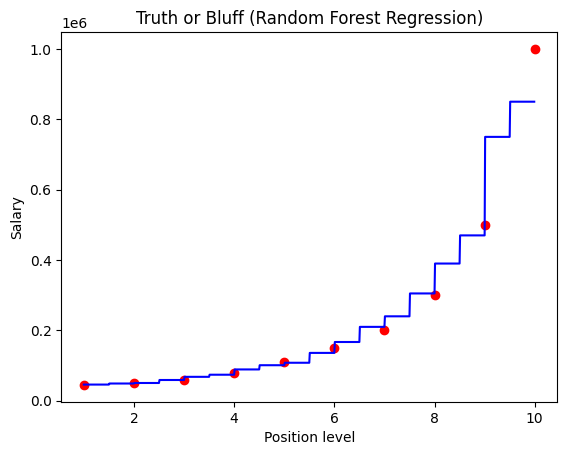

In [8]:
# Create a grid of X values from the minimum to maximum of the dataset
# Use X.min() and X.max() instead of min(X), max(X) because X is a NumPy array
X_grid = np.arange(X.min(), X.max(), 0.01)

# Reshape X_grid into a 2D array (required for prediction)
X_grid = X_grid.reshape((len(X_grid), 1))

# Scatter plot of the original data points (red dots)
plt.scatter(X, y, color='red')

# Plot the Random Forest regression predictions over the grid (blue line)
plt.plot(X_grid, regressor.predict(X_grid), color='blue')

# Add title and axis labels for clarity
plt.title('Truth or Bluff (Random Forest Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')

# Display the plot
plt.show()

In [ ]:
# Import libraries
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

# Train Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=10, random_state=0)
regressor.fit(X, y)

# Function to predict salary
def predict_salary(position_level):
    prediction = regressor.predict([[position_level]])[0]
    return f"Predicted Salary for level {position_level}: ₹{prediction:,.2f}"

# Function to plot regression curve
def plot_regression(position_level):
    X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='red', label="Actual Data")
    plt.plot(X_grid, regressor.predict(X_grid), color='blue', label="Random Forest Prediction")
    plt.scatter(position_level, regressor.predict([[position_level]]), color='green', s=100, label="Your Input")
    plt.title("Truth or Bluff (Random Forest Regression)")
    plt.xlabel("Position level")
    plt.ylabel("Salary")
    plt.legend()
    plt.tight_layout()
    return plt

# Build Gradio interface
with gr.Blocks() as demo:
    gr.Markdown("##  Random Forest Regression Demo\nEnter a position level to predict salary.")
    
    inp = gr.Number(label="Enter Position Level", value=6.5)
    out_text = gr.Textbox(label="Prediction")
    out_plot = gr.Plot(label="Regression Curve")
    
    btn = gr.Button("Predict")
    
    btn.click(fn=predict_salary, inputs=inp, outputs=out_text)
    btn.click(fn=plot_regression, inputs=inp, outputs=out_plot)

# Launch the app
demo.launch()


C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Random Forest Q&A

### 1. What is Random Forest?
- **Answer:** Random Forest is an ensemble learning method that builds many decision trees and combines their results.  
  - For regression → it averages predictions.  
  - For classification → it takes a majority vote.

---

### 2. Why do we use multiple trees instead of one?
- **Answer:** A single decision tree can easily overfit or underfit.  
- Random Forest reduces this risk by combining many trees, making predictions more stable and accurate.  
- **Analogy:** Asking 100 people for advice is usually better than asking just 1.

---

### 3. What does `n_estimators` mean?
- **Answer:** It is the number of trees in the forest.  
- More trees → more stable predictions, but slower training.  
- **Example:** 10 trees = quick but less stable, 100 trees = slower but more reliable.

---

### 4. What is the difference between regression and classification in Random Forest?
- **Answer:**  
  - **Regression:** Predicts continuous values (e.g., salary, house price).  
  - **Classification:** Predicts categories (e.g., spam vs not spam).  
- Same parameters, but the **criterion** changes (`mse` for regression, `gini/entropy` for classification).

---

### 5. How does Random Forest prevent overfitting?
- **Answer:**  
  - Uses **bootstrap sampling** (each tree sees different data).  
  - Uses **random feature selection** (each split considers different features).  
  - Combines results → balances out extremes.  
- **Analogy:** Instead of one student memorizing the textbook, the whole class studies different parts and shares knowledge.
